In [10]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import matplotlib.patches as mpatches
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [3]:
sns.set_theme(style="whitegrid")
df=load_raw_data()
df.head(10)

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K
5,2025-06-01,52,Male,Oceania,Customer Service,Business Analyst,Onsite,61,Burnout,Medium,4,Back Pain; Shoulder Pain,3,$60K-80K
6,2025-06-01,50,Female,Asia,Manufacturing,IT Support,Onsite,62,NaN,Medium,4,Back Pain; Shoulder Pain; Wrist Pain,2,$80K-100K
7,2025-06-01,63,Non-binary,Europe,Professional Services,Technical Writer,Onsite,55,Anxiety,High,3,NaN,2,$100K-120K
8,2025-06-01,30,Female,South America,Technology,Software Engineer,Remote,47,Anxiety,Medium,2,Neck Pain,4,$60K-80K
9,2025-06-01,37,Female,Asia,Finance,HR Manager,Onsite,55,Burnout,Medium,5,Back Pain,1,$60K-80K


### 1.1. Phân bố Độ tuổi và Giới tính
Độ tuổi và Giới tính phân bố như thế nào trong tập dữ liệu? 
Nhóm tuổi nào tham gia khảo sát nhiều nhất? Chúng ta sẽ trực quan hóa bằng biểu đồ Histogram kết hợp với KDE (Kernel Density Estimate).

In [4]:
df['Gender'] = df['Gender'].replace({
    'Non-binary': 'Other',
    'Prefer not to say': 'Other'
})
df.groupby('Gender').size()

Gender
Female    1500
Male      1535
Other      122
dtype: int64

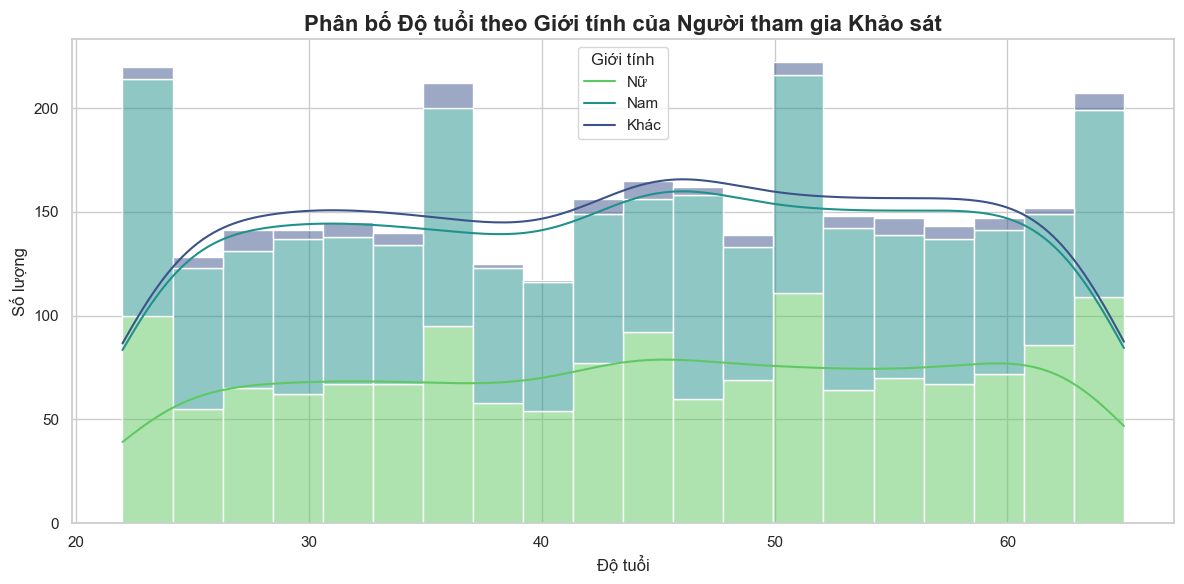

In [5]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='Age', hue='Gender', hue_order=['Other', 'Male', 'Female'], multiple='stack', bins=20, kde=True, palette='viridis')

plt.title('Phân bố Độ tuổi theo Giới tính của Người tham gia Khảo sát', fontsize=16, fontweight='bold')
plt.xlabel('Độ tuổi', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(title='Giới tính', labels=['Nữ', 'Nam', 'Khác']) 
plt.tight_layout()
plt.show()

* **Biểu đồ:** Histogram kết hợp đường KDE thể hiện mật độ phân bố độ tuổi theo từng nhóm giới tính.
* **Nhận xét (Observation):** Dữ liệu cho thấy độ tuổi của người tham gia tập trung chủ yếu ở khoảng 45-55 tuổi. Nhóm giới tính nam và nữ có số lượng gần như bằng nhau trong dữ liệu .
* **Insight (Sự thật ngầm hiểu):** Lực lượng lao động tham gia khảo sát phần lớn thuộc thế hệ cũ, đây là nhóm tuổi có mức độ thích nghi thấp hơn với thời đại công nghệ số so với các nhóm tuổi trẻ như genZ.
* **Đề xuất (Recommendation):** Khi phân tích các chỉ số sức khỏe ở các phần sau, cần lưu ý kiểm soát biến số độ tuổi, vì nhóm tuổi này có mức độ chịu đựng trong công việc lớn, mức độ ổn định cao gặp ít vấn đề về tinh thần nhưng có thể có nhiều vấn đề về thể chất.

C:\Users\HPC\AppData\Local\Temp\ipykernel_3288\3593533100.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


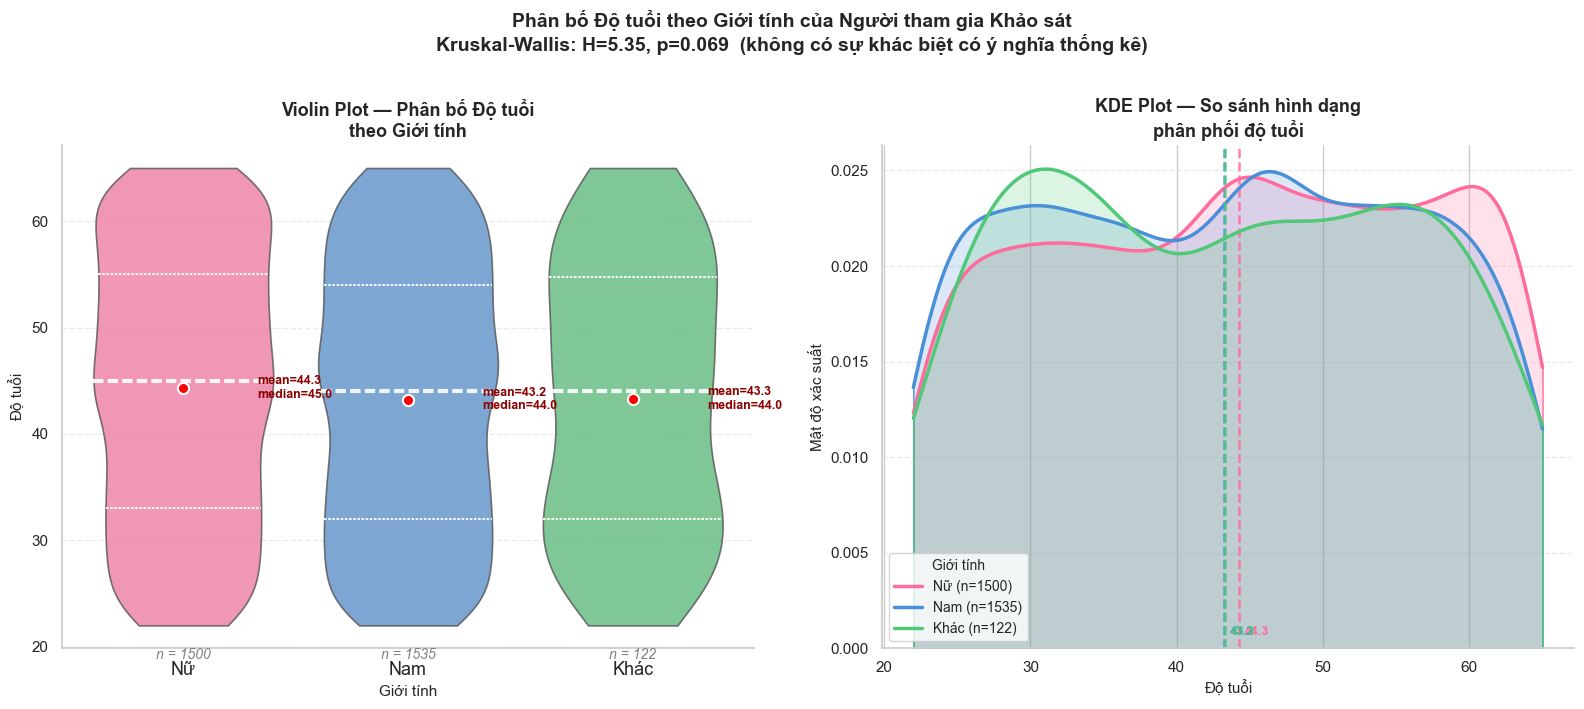

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy import stats

gender_order  = ['Female', 'Male', 'Other']
gender_labels = {'Female': 'Nữ', 'Male': 'Nam', 'Other': 'Khác'}
palette       = {'Female': '#FF6B9D', 'Male': '#4A90D9', 'Other': '#50C878'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ──────────────────────────────────────────────
# PLOT 1 — Violin tách đôi + boxplot nhỏ gọn
# ──────────────────────────────────────────────
ax = axes[0]

sns.violinplot(
    data=df, x='Gender', y='Age',
    order=gender_order,
    palette=palette,
    inner='quartile',   # Chỉ vẽ 3 đường quartile bên trong, không boxplot đen to
    cut=0,
    linewidth=1.2,
    alpha=0.8,
    ax=ax
)

# Chỉnh đường quartile bên trong violin
for line in ax.lines:
    line.set_linewidth(1.5)
    line.set_color('white')
    line.set_alpha(0.9)

# Median nổi bật hơn (mỗi 3 đường = Q1, median, Q3)
for i, line in enumerate(ax.lines):
    if i % 3 == 1:   # đường giữa = median
        line.set_linewidth(3)
        line.set_color('white')

# Mean marker
for i, gender in enumerate(gender_order):
    subset = df[df['Gender'] == gender]['Age']
    mean_val = subset.mean()
    median_val = subset.median()
    n = len(subset)

    ax.plot(i, mean_val, 'o', color='red', markersize=8,
            zorder=5, markeredgecolor='white', markeredgewidth=1.5)
    ax.text(i + 0.33, mean_val,
            f'mean={mean_val:.1f}\nmedian={median_val:.1f}',
            va='center', fontsize=9, color='darkred', fontweight='bold')
    ax.text(i, ax.get_ylim()[0] - 1,
            f'n = {n}', ha='center', fontsize=10,
            color='gray', style='italic')

ax.set_xticks(range(len(gender_order)))
ax.set_xticklabels([gender_labels[g] for g in gender_order], fontsize=13)
ax.set_title('Violin Plot — Phân bố Độ tuổi\ntheo Giới tính', fontsize=13, fontweight='bold')
ax.set_xlabel('Giới tính', fontsize=11)
ax.set_ylabel('Độ tuổi', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

# ──────────────────────────────────────────────
# PLOT 2 — KDE thuần: thấy rõ hình dạng phân phối
# ──────────────────────────────────────────────
ax2 = axes[1]

for gender in gender_order:
    subset = df[df['Gender'] == gender]['Age']
    color  = palette[gender]
    label  = gender_labels[gender]
    n      = len(subset)

    # Vùng fill
    sns.kdeplot(subset, ax=ax2, color=color,
                fill=True, alpha=0.20, cut=0, bw_adjust=0.9)
    # Đường viền
    sns.kdeplot(subset, ax=ax2, color=color,
                linewidth=2.5, cut=0, bw_adjust=0.9,
                label=f'{label} (n={n})')

    # Đường mean dọc
    mean_val = subset.mean()
    ax2.axvline(mean_val, color=color, linestyle='--',
                linewidth=1.8, alpha=0.85)
    ax2.text(mean_val + 0.4, ax2.get_ylim()[1] * 0.02,
             f'{mean_val:.1f}', color=color,
             fontsize=9, fontweight='bold', va='bottom')

ax2.set_title('KDE Plot — So sánh hình dạng\nphân phối độ tuổi', fontsize=13, fontweight='bold')
ax2.set_xlabel('Độ tuổi', fontsize=11)
ax2.set_ylabel('Mật độ xác suất', fontsize=11)
ax2.legend(title='Giới tính', fontsize=10, title_fontsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
sns.despine(ax=ax2)

# ──────────────────────────────────────────────
# Kruskal-Wallis test — hiển thị lên figure
# ──────────────────────────────────────────────
groups = [df[df['Gender'] == g]['Age'].dropna() for g in gender_order]
stat, p_value = stats.kruskal(*groups)
p_text = f'Kruskal-Wallis: H={stat:.2f}, p={p_value:.3f}'
significance = '(không có sự khác biệt có ý nghĩa thống kê)' if p_value > 0.05 \
               else '(có sự khác biệt có ý nghĩa thống kê ✓)'

fig.suptitle(
    f'Phân bố Độ tuổi theo Giới tính của Người tham gia Khảo sát\n'
    f'{p_text}  {significance}',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

* **iểu đồ:** Violin Plot kết hợp KDE thể hiện hình dạng phân phối độ tuổi theo từng nhóm giới tính (Nữ: n=1.500, Nam: n=1.535, Khác: n=122). Kiểm định Kruskal-Wallis được áp dụng để đánh giá sự khác biệt giữa các nhóm.
* **Nhận xét (Observation):** Độ tuổi người tham gia trải rộng từ khoảng 20 đến 65 tuổi, không tập trung nhọn ở một khoảng duy nhất mà phân bổ tương đối đồng đều. Cả ba nhóm giới tính có độ tuổi trung bình rất gần nhau: Nữ (mean=44,3), Nam (mean=43,2) và Khác (mean=43,3). Kiểm định Kruskal-Wallis cho kết quả H=5,35, p=0,069 — không có sự khác biệt có ý nghĩa thống kê về độ tuổi giữa các nhóm giới tính.
* **Insight (Sự thật ngầm hiểu):** Với độ tuổi trung bình xấp xỉ 43–44 tuổi, phần lớn người tham gia khảo sát thuộc thế hệ Gen X (1965–1980) và nhóm Millennials lớn tuổi (1981–1985). Đây là nhóm đang ở giai đoạn đỉnh cao sự nghiệp, chịu áp lực kép giữa trách nhiệm công việc và gia đình, đồng thời là thế hệ trải qua nhiều biến động lớn về môi trường làm việc hậu đại dịch. Sự tương đồng về cấu trúc tuổi giữa các nhóm giới tính cho thấy mẫu khảo sát không bị lệch về nhân khẩu học, tăng tính đại diện cho phân tích.
* **Đề xuất (Recommendation):** Mặc dù độ tuổi không có sự khác biệt đáng kể giữa các nhóm giới tính, biến số này vẫn cần được kiểm soát (control variable) trong các phân tích tiếp theo — đặc biệt khi đánh giá các chỉ số sức khỏe thể chất và tinh thần. Nhóm tuổi 40+ thường có nguy cơ cao hơn với các bệnh mãn tính liên quan đến stress nghề nghiệp và kiệt sức (burnout), do đó các khuyến nghị về sức khỏe nơi làm việc cần được cá nhân hóa theo độ tuổi thay vì áp dụng đồng nhất.

### 1.2. Phân bố Khu vực (Region)
Tiếp theo, chúng ta sẽ đánh giá sự tham gia của người lao động theo các khu vực (Region) địa lý khác nhau.

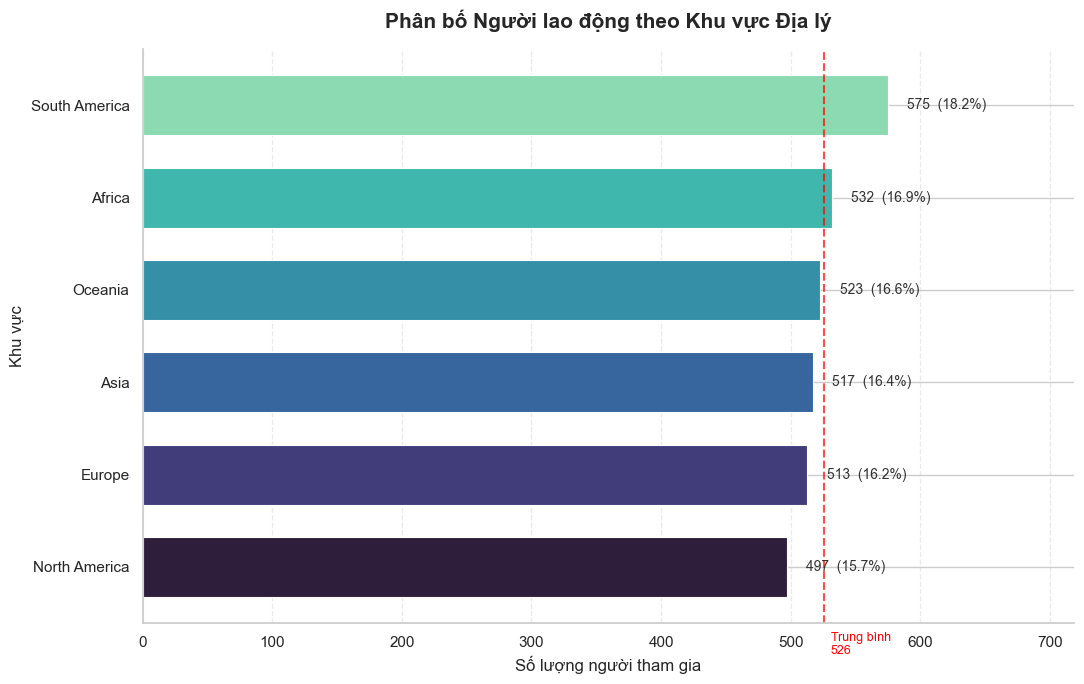

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))

region_counts = df['Region'].value_counts().sort_values(ascending=True)  # ascending để bar dài nhất ở trên
total = region_counts.sum()
colors = sns.color_palette('mako', len(region_counts))

bars = ax.barh(region_counts.index, region_counts.values,
               color=colors, edgecolor='white', linewidth=0.8, height=0.65)

# --- Số lượng + % trên mỗi bar ---
for bar, val in zip(bars, region_counts.values):
    pct = val / total * 100
    ax.text(val + 15, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=10, color='#333333')

# --- Đường trung bình ---
mean_val = region_counts.mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(mean_val + 5, -0.7, f'Trung bình\n{mean_val:.0f}',
        color='red', fontsize=9, va='top')

# --- Styling ---
ax.set_title('Phân bố Người lao động theo Khu vực Địa lý',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Số lượng người tham gia', fontsize=12)
ax.set_ylabel('Khu vực', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Mở rộng trục x để label không bị cắt
ax.set_xlim(0, region_counts.max() * 1.25)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

* **Biểu đồ:** Bar chart (Biểu đồ cột) thể hiện số lượng người tham gia theo từng khu vực địa lý.
* **Nhận xét (Observation):** Khu vực South America có số lượng người tham gia khảo sát đông đảo nhất với 575 người, trong khi khu vực North America có tỷ lệ tham gia thấp nhất, nhưng độ chệnh lệnh không quá lớn nên các phân tích về sau có thể đảm bảo hơn.
* **Insight (Sự thật ngầm hiểu):** Sự chênh lệch về số lượng người tham gia có thể phản ánh mức độ tập trung của các ngành nghề công nghệ/dịch vụ hoặc mức độ áp dụng xu hướng làm việc từ xa ở các vùng kinh tế khác nhau. 

### 2. Phân tích Đặc điểm và Hình thức Công việc
Tiếp theo, chúng ta sẽ xem xét các đặc thù về công việc, bắt đầu bằng việc phân tích tỉ lệ các hình thức làm việc. Đây là biến số (feature) cốt lõi của toàn bộ dự án.

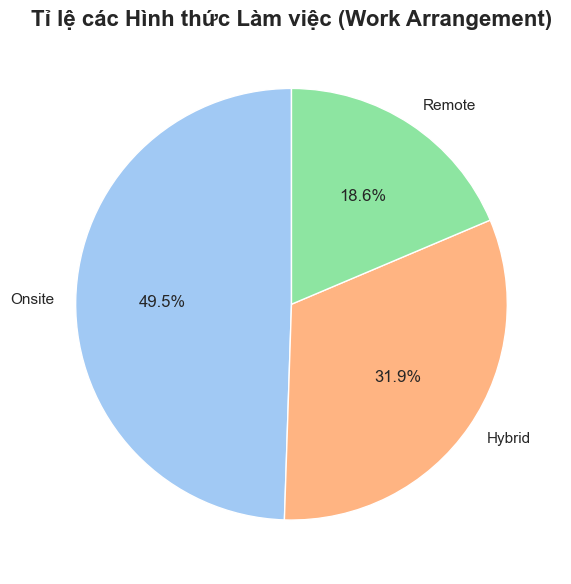

In [ ]:
plt.figure(figsize=(8, 6))

# Đếm số lượng từng hình thức làm việc
work_counts = df['Work_Arrangement'].value_counts()

# Vẽ biểu đồ tròn (Pie chart) để xem tỷ lệ phần trăm
plt.pie(work_counts.values, labels=work_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90, wedgeprops={'edgecolor': 'white'})

plt.title('Tỉ lệ các Hình thức Làm việc (Work Arrangement)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

* **Biểu đồ:** Biểu đồ tròn (Pie chart) thể hiện tỷ lệ phần trăm của 3 nhóm hình thức làm việc.
* **Nhận xét (Observation):** Hình thức làm việc Onsite chiếm tỷ trọng lớn nhất với 49.5%.
* **Insight:** Dữ liệu cho thấy xu hướng làm việc Onsite đang là hình thái chủ đạo đối với tập người dùng tham gia khảo sát trong năm 2025.

### 2.1. Sự phân bổ Hình thức làm việc theo Ngành nghề (Industry)
Liệu có phải ngành IT thì làm Remote nhiều hơn, trong khi ngành Sản xuất thì bắt buộc phải làm Onsite? Chúng ta sẽ kiểm chứng bằng biểu đồ đếm kết hợp (Grouped Bar Chart).

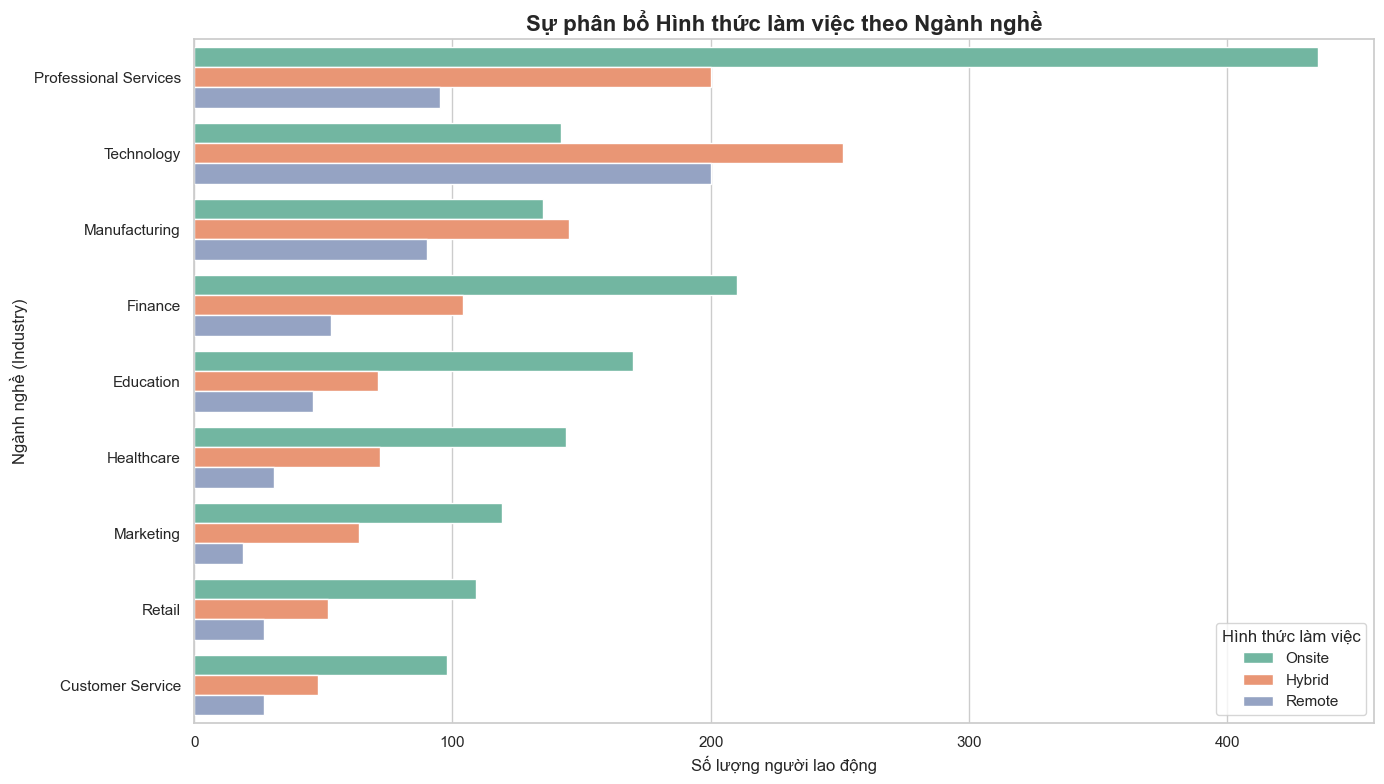

In [ ]:
plt.figure(figsize=(14, 8))

# Vẽ biểu đồ cột ngang thể hiện ngành nghề, chia màu theo hình thức làm việc
sns.countplot(data=df, y='Industry', hue='Work_Arrangement', palette='Set2', 
              order=df['Industry'].value_counts().index)

plt.title('Sự phân bổ Hình thức làm việc theo Ngành nghề', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng người lao động', fontsize=12)
plt.ylabel('Ngành nghề (Industry)', fontsize=12)
plt.legend(title='Hình thức làm việc')
plt.tight_layout()
plt.show()

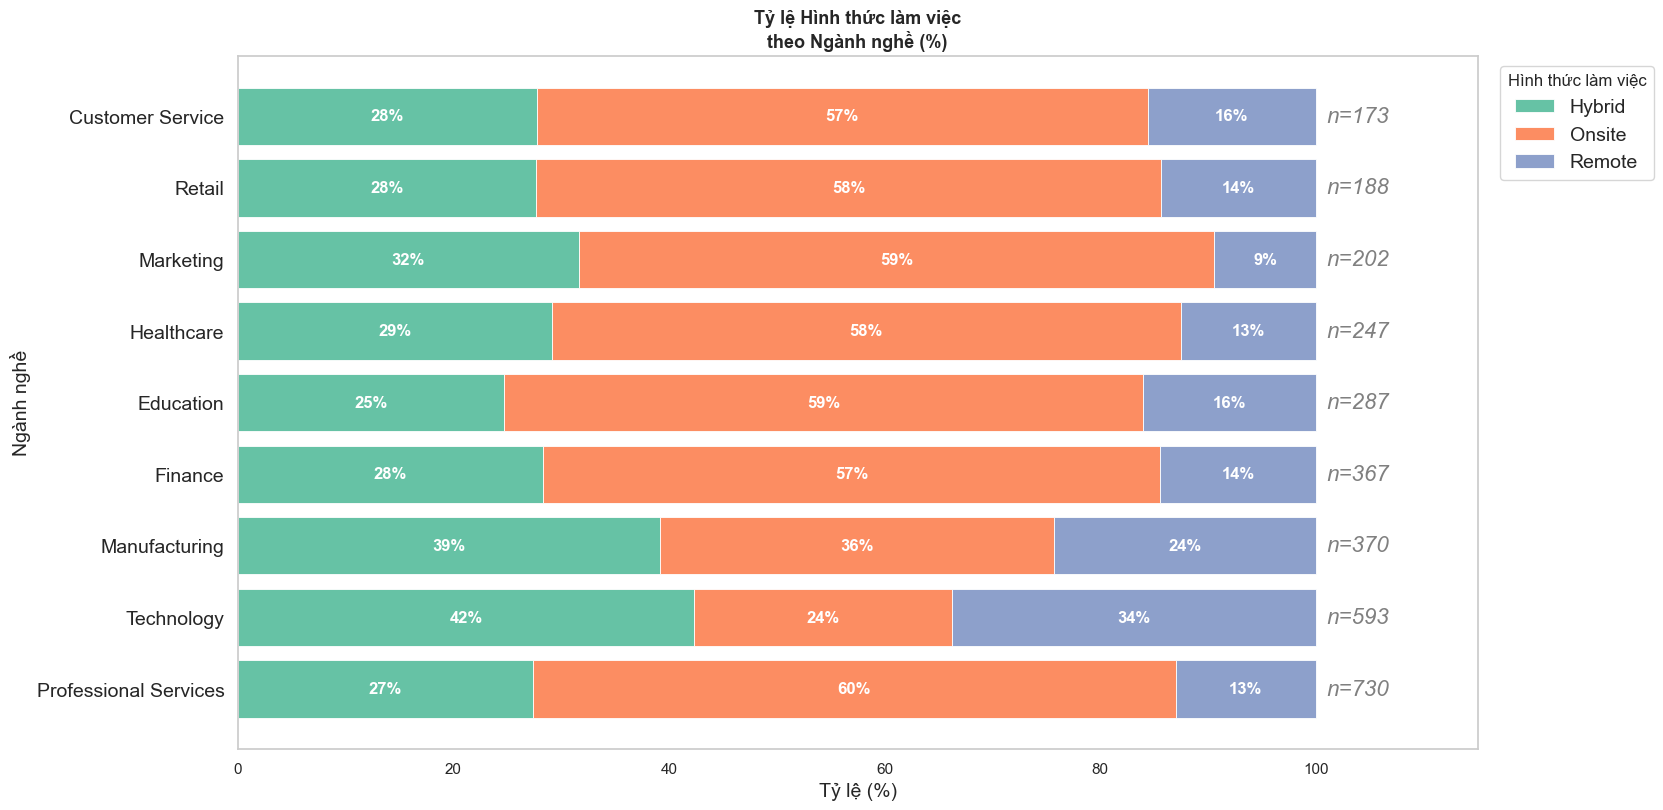

In [ ]:
fig, axes = plt.subplots(figsize=(16, 9))

# ── Dữ liệu chuẩn bị ──
industry_order = df['Industry'].value_counts().index.tolist()
work_arr_order = df['Work_Arrangement'].value_counts().index.tolist()

# Pivot table tỷ lệ % theo từng ngành
pivot_count = df.groupby(['Industry', 'Work_Arrangement']).size().unstack(fill_value=0)
pivot_pct   = pivot_count.div(pivot_count.sum(axis=1), axis=0) * 100
pivot_pct   = pivot_pct.loc[industry_order]  # giữ thứ tự

palette = sns.color_palette('Set2', len(work_arr_order))
color_map = dict(zip(pivot_pct.columns, palette))

bottom = np.zeros(len(pivot_pct))
for work_type in pivot_pct.columns:
    values = pivot_pct[work_type].values
    bars = axes.barh(pivot_pct.index, values,
                    left=bottom, color=color_map[work_type],
                    label=work_type, edgecolor='white', linewidth=0.6)
    # Label % bên trong bar nếu đủ rộng
    for bar, val, bot in zip(bars, values, bottom):
        if val > 8:
            axes.text(bot + val / 2, bar.get_y() + bar.get_height() / 2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=12, color='white', fontweight='bold')
    bottom += values

# Tổng số n mỗi ngành
totals = pivot_count.sum(axis=1).loc[industry_order]
for i, (industry, total) in enumerate(totals.items()):
    axes.text(101, i, f'n={total:,}', va='center',
             fontsize=16, color='gray', style='italic')

axes.set_xlim(0, 115)
axes.tick_params(axis='y', labelsize=14)
axes.set_xlabel('Tỷ lệ (%)', fontsize=14)
axes.set_ylabel('Ngành nghề', fontsize=14)
axes.set_title('Tỷ lệ Hình thức làm việc\ntheo Ngành nghề (%)', 
              fontsize=13, fontweight='bold')
axes.axvline(100, color='gray', linewidth=0.8, linestyle='--')
axes.legend(title='Hình thức làm việc', bbox_to_anchor=(1.01, 1),
           loc='upper left', fontsize=14)
axes.grid(False)
axes.set_axisbelow(True)
sns.despine(ax=ax1)


* **Biểu đồ:** Biểu đồ cột ngang (Horizontal Bar Chart) được nhóm theo hình thức làm việc.
* **Nhận xét (Observation):** Ngành [điền tên ngành] có số lượng người tham gia đông nhất, và trong ngành này, tỷ lệ làm việc [điền hình thức] áp đảo hoàn toàn. Ngược lại, ngành [điền tên ngành] chủ yếu duy trì hình thức [điền hình thức].
* **Insight:** Sự khác biệt về hình thức làm việc phụ thuộc rất lớn vào đặc thù ngành nghề (ví dụ: các ngành cần thao tác vật lý hoặc giao tiếp trực tiếp sẽ khó áp dụng Remote toàn thời gian).
* **Đề xuất:** Khi phân tích các vấn đề về sức khỏe (như đau lưng, mỏi mắt), cần xem xét song song với yếu tố "Ngành nghề" chứ không chỉ đổ lỗi hoàn toàn cho "Làm việc từ xa".